The case study is from a dataset from Kaggle. 

Link to the Kaggle project site:

https://www.kaggle.com/c/plant-seedlings-classification (Links to an external site.)Links to an external site.


The dataset has to be downloaded from the above Kaggle web site.


Can you differentiate a weed from a crop seedling?

The ability to do so effectively can mean better crop yields and better stewardship of the environment.

The Aarhus University Signal Processing group, in collaboration with the University of Southern Denmark, has recently released a dataset containing images of approximately 960 unique plants belonging to 12 species at several growth stages.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import cv2
from glob import glob
import itertools
import os

In [2]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID" 
os.environ["CUDA_VISIBLE_DEVICES"] = ""

In [3]:
from keras.utils import np_utils
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers import Flatten
from keras.layers.convolutional import Conv2D
from keras.layers.convolutional import MaxPooling2D
from keras.layers import BatchNormalization
from keras.callbacks import ModelCheckpoint,ReduceLROnPlateau,CSVLogger

Using TensorFlow backend.
/home/siju/.local/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
/home/siju/.local/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
/home/siju/.local/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
/home/siju/.local/lib/python3.6/site-packages/tensorflow/python/framewo

In [4]:
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [5]:
from tensorflow.python.framework import ops
ops.reset_default_graph()

In [6]:
%matplotlib inline
plt.rcParams['figure.figsize'] = [16, 10]
plt.rcParams['font.size'] = 16

# 1. Read the images and generate the train and test dataset (10 points)

In [7]:
#List of Classes/Labels
os.listdir("./train")

['Black-grass',
 'Charlock',
 'Cleavers',
 'Common Chickweed',
 'Common wheat',
 'Fat Hen',
 'Loose Silky-bent',
 'Maize',
 'Scentless Mayweed',
 'Shepherds Purse',
 'Small-flowered Cranesbill',
 'Sugar beet']

In [8]:
train = "train/*/*.png"
test = "test/*.png"

In [9]:
train_files = glob(train)
test_files = glob(test)

In [10]:
train_images = []
train_label = []
for img in train_files:
    images=cv2.imread(img)
    train_images.append(cv2.resize(images, (70,70,)))
    train_label.append(img.split('/')[-2])

train_images = np.asarray(train_images)
train_label = pd.DataFrame(train_label)

In [11]:
print("The shape of train images is:",train_images.shape)
print(("The shape of train labels is:",train_label.shape))

The shape of train images is: (4750, 70, 70, 3)
('The shape of train labels is:', (4750, 1))


In [12]:
test_images = []
test_label = []
for img in test_files:
    images=cv2.imread(img)
    test_images.append(cv2.resize(images, (70,70,)))
    test_label.append(img.split('/')[-2])

test_images = np.asarray(test_images)
test_label = pd.DataFrame(test_label)

In [13]:
print("The shape of train images is:",test_images.shape)
print(("The shape of train labels is:",test_label.shape))

The shape of train images is: (794, 70, 70, 3)
('The shape of train labels is:', (794, 1))


(388, 388, 3) (70, 70, 3)


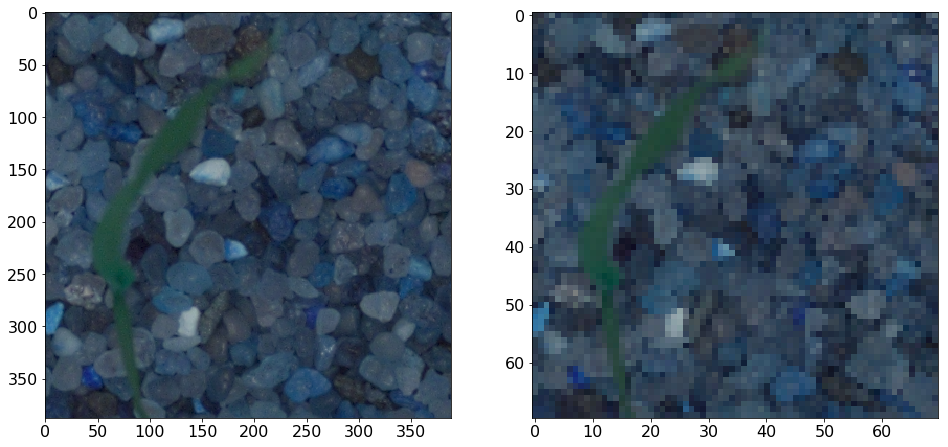

In [14]:
#View one sample image
sample_image_scale = train_images[1]
sample_image_orig = cv2.imread(train_files[1])
print(sample_image_orig.shape, sample_image_scale.shape)
plt.subplot(1,2,1)
plt.imshow(sample_image_orig)
plt.subplot(1,2,2)
plt.imshow(sample_image_scale)

In [15]:
train_images = train_images/255

In [16]:
label_encoder = preprocessing.LabelEncoder()
label_encoder.fit(train_label[0])
encoded_train_labels = label_encoder.transform(train_label[0])
encoded_labels = np_utils.to_categorical(encoded_train_labels)
classes = encoded_labels.shape[0]
print('Classes'+str(label_encoder.classes_))
print(str(classes))

Classes['Black-grass' 'Charlock' 'Cleavers' 'Common Chickweed' 'Common wheat'
 'Fat Hen' 'Loose Silky-bent' 'Maize' 'Scentless Mayweed'
 'Shepherds Purse' 'Small-flowered Cranesbill' 'Sugar beet']
4750


# 2. Divide the data set into Train and validation data sets

In [17]:
X_train, X_val, y_train, y_val = train_test_split(train_images, encoded_labels, test_size=0.1, random_state=7, stratify = encoded_labels)

# 3. Initialize & build the model (20 points)

In [18]:
model = Sequential()
model.add(Conv2D(32,(3, 3), input_shape=(70,70,3),activation= 'relu'))
model.add(Conv2D(32,(3, 3),activation= 'relu'))
model.add(MaxPooling2D())
model.add(Flatten())
model.add(Dense(512, activation= 'relu'))
model.add(Dense(12, activation='softmax'))

In [19]:
model.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [20]:
print(model.summary())

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_1 (Conv2D)            (None, 68, 68, 32)        896       
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 66, 66, 32)        9248      
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 33, 33, 32)        0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 34848)             0         
_________________________________________________________________
dense_1 (Dense)              (None, 512)               17842688  
_________________________________________________________________
dense_2 (Dense)              (None, 12)                6156      
Total params: 17,858,988
Trainable params: 17,858,988
Non-trainable params: 0
________________________________________________________________

In [21]:
model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs= 10, batch_size=10)

Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where

Train on 4275 samples, validate on 475 samples
Epoch 1/10
4275/4275 [==============================] - 74s 17ms/step - loss: 1.4759 - acc: 0.4980 - val_loss: 1.2533 - val_acc: 0.5916
Epoch 2/10
4275/4275 [==============================] - 72s 17ms/step - loss: 0.9135 - acc: 0.6880 - val_loss: 0.8995 - val_acc: 0.7011
Epoch 3/10
4275/4275 [==============================] - 73s 17ms/step - loss: 0.6227 - acc: 0.7808 - val_loss: 0.9234 - val_acc: 0.6842
Epoch 4/10
4275/4275 [==============================] - 74s 17ms/step - loss: 0.3898 - acc: 0.8683 - val_loss: 0.9167 - val_acc: 0.7200
Epoch 5/10
4275/4275 [==============================] - 74s 17ms/step - loss: 0.2128 - acc: 0.9317 - val_loss: 1.0378 - val_acc: 0.7221
Epoch 6/10
4275/4275 [==============================] - 73s 17ms/step - loss: 0.1172 - acc: 0.9630 - val_loss: 1.1776 - val_acc: 0.7305
Epoch 7/10
4275/4275 [====================

# 4. Optimize the model (16 points)

In [22]:
loss_and_metrics_1 = model.evaluate(X_train, y_train)
print(loss_and_metrics_1)

4275/4275 [==============================] - 3s 691us/step
[0.009430836339246983, 0.9981286549707602]


In [23]:
loss_and_metrics_2 = model.evaluate(X_val, y_val)
print(loss_and_metrics_2)

475/475 [==============================] - 0s 699us/step
[1.3777507069236354, 0.7431578946113586]


In [24]:
y_pred = model.predict(X_val)
y_class = np.argmax(y_pred, axis = 1) 
y_check = np.argmax(y_val, axis = 1) 

#Print confusion matrix
cmatrix = confusion_matrix(y_check, y_class)
print(cmatrix)

[[ 4  0  0  0  7  0 15  0  0  0  0  0]
 [ 1 34  1  0  0  1  0  0  0  0  2  0]
 [ 0  1 25  0  1  1  0  0  1  0  0  0]
 [ 0  0  0 58  0  1  0  1  0  0  0  1]
 [ 0  1  0  0 15  2  3  0  0  0  0  1]
 [ 1  0  0  4  6 31  1  1  0  0  1  2]
 [ 7  0  0  0  7  5 45  1  0  0  0  0]
 [ 0  1  0  2  0  1  0 16  0  0  0  2]
 [ 0  0  1  3  1  1  0  0 42  2  0  2]
 [ 0  0  0  5  0  1  0  3  1 13  0  0]
 [ 0  1  0  0  0  1  0  1  0  0 45  2]
 [ 0  3  1  1  2  2  0  1  2  0  2 25]]


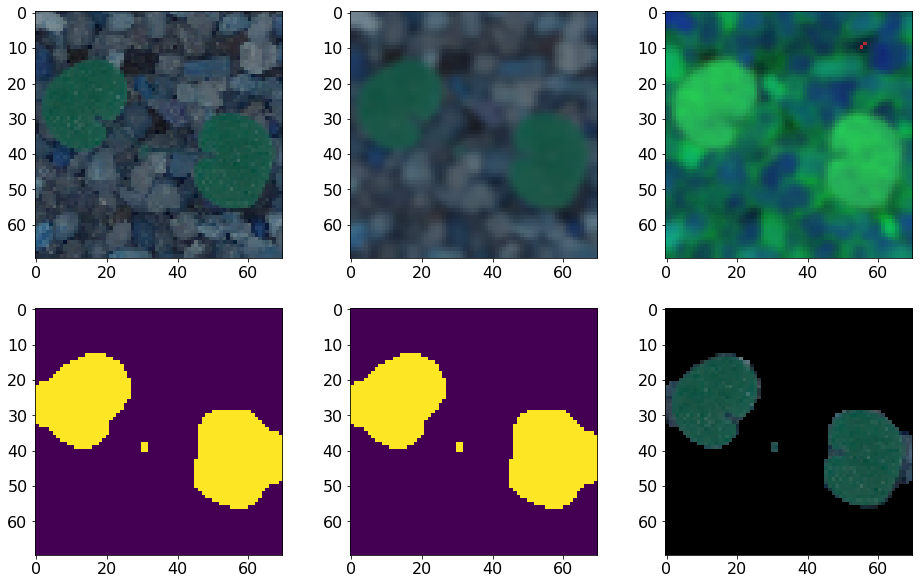

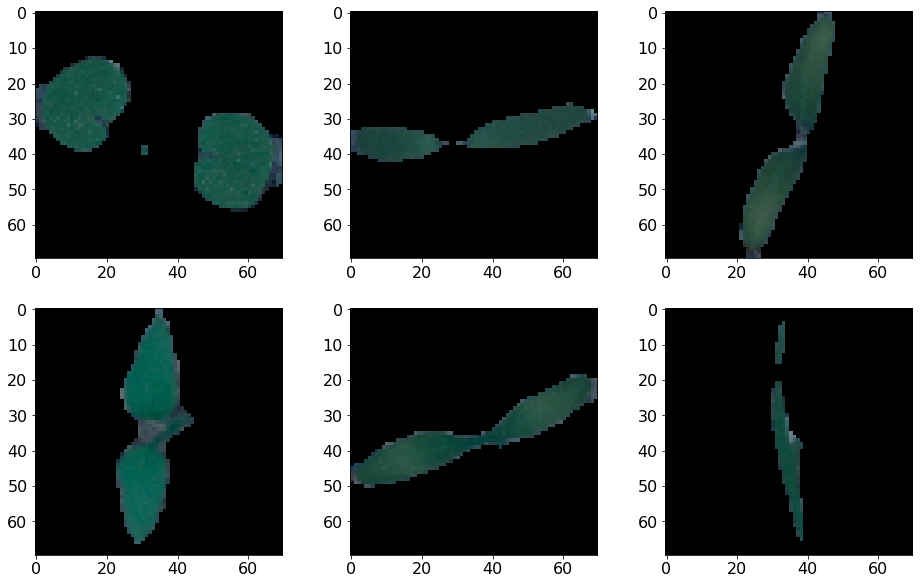

In [25]:
testimages = []
sets = []
getEx = True
for i in test_images:
    blurr = cv2.GaussianBlur(i,(5,5),0)
    hsv = cv2.cvtColor(blurr,cv2.COLOR_BGR2HSV)
    
    lower = (25,40,50)
    upper = (75,255,255)
    mask = cv2.inRange(hsv,lower,upper)
    struc = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(11,11))
    mask = cv2.morphologyEx(mask,cv2.MORPH_CLOSE,struc)
    boolean = mask>0
    masking = np.zeros_like(i,np.uint8)
    masking[boolean] = i[boolean]
    testimages.append(masking)
    
    if getEx:
        plt.subplot(2,3,1);plt.imshow(i)
        plt.subplot(2,3,2);plt.imshow(blurr)
        plt.subplot(2,3,3);plt.imshow(hsv)
        plt.subplot(2,3,4);plt.imshow(mask)
        plt.subplot(2,3,5);plt.imshow(boolean)
        plt.subplot(2,3,6);plt.imshow(masking)
        plt.show()
        getEx=False

testimages = np.asarray(testimages)
# OTHER MASKED IMAGES
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(testimages[i])

In [26]:
model1 = Sequential()

model1.add(Conv2D(filters=64, kernel_size=(3,3), input_shape=(70, 70, 3), activation='relu'))
model1.add(BatchNormalization(axis=3))
model1.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
model1.add(MaxPooling2D((2, 2)))
model1.add(BatchNormalization(axis=3))
model1.add(Dropout(0.12))

model1.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu'))
model1.add(BatchNormalization(axis=3))
model1.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu'))
model1.add(MaxPooling2D((2, 2)))
model1.add(BatchNormalization(axis=3))
model1.add(Dropout(0.12))

model1.add(Conv2D(filters=256, kernel_size=(3,3), activation='relu'))
model1.add(BatchNormalization(axis=3))
model1.add(Conv2D(filters=256, kernel_size=(3,3), activation='relu'))
model1.add(MaxPooling2D((2, 2)))
model1.add(BatchNormalization(axis=3))
model1.add(Dropout(0.12))

model1.add(Flatten())

model1.add(Dense(256, activation='relu'))
model1.add(BatchNormalization())
model1.add(Dropout(0.25))

model1.add(Dense(256, activation='relu'))
model1.add(BatchNormalization())
model1.add(Dropout(0.25))

model1.add(Dense(256, activation='relu'))
model1.add(BatchNormalization())
model1.add(Dropout(0.25))

model1.add(Dense(256, activation='relu'))
model1.add(BatchNormalization())
model1.add(Dropout(0.25))

model1.add(Dense(12, activation='softmax'))


Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.


In [27]:
print(model1.summary())

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_3 (Conv2D)            (None, 68, 68, 64)        1792      
_________________________________________________________________
batch_normalization_1 (Batch (None, 68, 68, 64)        256       
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 66, 66, 64)        36928     
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 33, 33, 64)        0         
_________________________________________________________________
batch_normalization_2 (Batch (None, 33, 33, 64)        256       
_________________________________________________________________
dropout_1 (Dropout)          (None, 33, 33, 64)        0         
_________________________________________________________________
conv2d_5 (Conv2D)            (None, 31, 31, 128)       73856     
__________

In [28]:
model1.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [44]:
#Save the model with best accuracy, do early stopping if the val-accuracy is not improving.
from keras.callbacks import ModelCheckpoint, EarlyStopping
checkpointer = ModelCheckpoint(filepath="bestmodel.h5", verbose=1, save_best_only=True)
earlystopper = EarlyStopping(monitor='val_loss', patience=15, verbose=1, restore_best_weights = True)
callbacks = [checkpointer, earlystopper]

In [45]:
model1.fit(X_train, y_train, validation_data=(X_val, y_val), epochs= 100, batch_size=100, callbacks=callbacks)

Train on 4275 samples, validate on 475 samples
Epoch 1/100
4275/4275 [==============================] - 84s 20ms/step - loss: 0.0286 - acc: 0.9902 - val_loss: 0.8597 - val_acc: 0.8505

Epoch 00001: val_loss improved from inf to 0.85969, saving model to bestmodel.h5
Epoch 2/100
4275/4275 [==============================] - 85s 20ms/step - loss: 0.0665 - acc: 0.9827 - val_loss: 0.9380 - val_acc: 0.8189

Epoch 00002: val_loss did not improve from 0.85969
Epoch 3/100
4275/4275 [==============================] - 85s 20ms/step - loss: 0.0393 - acc: 0.9876 - val_loss: 1.2790 - val_acc: 0.7474

Epoch 00003: val_loss did not improve from 0.85969
Epoch 4/100
4275/4275 [==============================] - 85s 20ms/step - loss: 0.0277 - acc: 0.9906 - val_loss: 0.7584 - val_acc: 0.8463

Epoch 00004: val_loss improved from 0.85969 to 0.75841, saving model to bestmodel.h5
Epoch 5/100
4275/4275 [==============================] - 85s 20ms/step - loss: 0.0193 - acc: 0.9942 - val_loss: 0.9446 - val_acc: 0.8

# 5. Predict the accuracy for both train and validation data (14 points)

In [46]:
loss_and_metrics_3 = model1.evaluate(X_train, y_train)
print(loss_and_metrics_3)

4275/4275 [==============================] - 17s 4ms/step
[0.0042975494301961655, 0.9985964912280701]


In [47]:
loss_and_metrics_4 = model1.evaluate(X_val, y_val)
print(loss_and_metrics_4)

475/475 [==============================] - 2s 4ms/step
[0.6837721014022827, 0.8842105279470744]


In [48]:
print("Train Accuracy = ", loss_and_metrics_3[1])
print("Test Accuracy = ", loss_and_metrics_4[1])

Train Accuracy =  0.9985964912280701
Test Accuracy =  0.8842105279470744
